In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/MedicalAI"
DATA_DIR = os.path.join(BASE_DIR, "symptom_data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
DATASET_PATH     = os.path.join(DATA_DIR, "dataset.csv")
DESCRIPTION_PATH = os.path.join(DATA_DIR, "symptom_Description.csv")
SEVERITY_PATH    = os.path.join(DATA_DIR, "Symptom-severity.csv")
PRECAUTION_PATH  = os.path.join(DATA_DIR, "symptom_precaution.csv")

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
df = pd.read_csv(DATASET_PATH)
df['Disease'] = df['Disease'].str.strip()

symptom_cols = [col for col in df.columns if col.startswith('Symptom_')]

In [6]:
# Normalize all symptom values
for col in symptom_cols:
    df[col] = df[col].str.strip().str.lower().str.replace(' ', '_')

print("Raw shape:", df.shape)
print("Diseases:", df['Disease'].nunique())
print("\nSamples per disease:")
print(df['Disease'].value_counts())

Raw shape: (4920, 18)
Diseases: 41

Samples per disease:
Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                               

In [8]:
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
print(f"\nTotal rows:     {total_rows}")
print(f"Duplicate rows: {duplicate_rows}  ({duplicate_rows/total_rows*100:.1f}%)")

df = df.drop_duplicates()
print(f"After removing duplicates: {len(df)} rows")


Total rows:     304
Duplicate rows: 0  (0.0%)
After removing duplicates: 304 rows


In [9]:
all_symptoms_set = set()
for col in symptom_cols:
    all_symptoms_set.update(df[col].dropna().unique())

all_symptoms = sorted(list(all_symptoms_set))
print(f"\nUnique symptoms: {len(all_symptoms)}")

binary_rows = []
for _, row in df.iterrows():
    present = set()
    for col in symptom_cols:
        val = row[col]
        if pd.notna(val) and val != '':
            present.add(val)
    binary_row = {s: 1 if s in present else 0 for s in all_symptoms}
    binary_row['Disease'] = row['Disease']
    binary_rows.append(binary_row)

binary_df = pd.DataFrame(binary_rows)

# FIX 2: Remove duplicates from binary matrix too
binary_df = binary_df.drop_duplicates()
print(f"Binary matrix shape after dedup: {binary_df.shape}")


Unique symptoms: 131
Binary matrix shape after dedup: (304, 132)


In [10]:
def augment_data(df, symptom_cols, noise_rate=0.05, augment_factor=3):
    """
    For each real row, create augmented copies by randomly
    flipping a small percentage of symptom bits.
    This simulates real-world variation (patients don't always have
    every symptom, or may have an extra one).
    """
    augmented = [df.copy()]  # start with original data

    for _ in range(augment_factor):
        noisy = df.copy()
        for col in symptom_cols:
            # Randomly flip bits with probability = noise_rate
            mask = np.random.random(len(noisy)) < noise_rate
            noisy.loc[mask, col] = 1 - noisy.loc[mask, col]
        augmented.append(noisy)

    result = pd.concat(augmented, ignore_index=True)
    result = result.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
    return result

augmented_df = augment_data(binary_df, all_symptoms, noise_rate=0.05, augment_factor=3)
print(f"\nAugmented dataset size: {len(augmented_df)} rows")


Augmented dataset size: 1216 rows


In [11]:
X = augmented_df[all_symptoms].values.astype(np.float32)
y_raw = augmented_df['Disease'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
disease_names = list(label_encoder.classes_)
num_classes   = len(disease_names)
num_symptoms  = len(all_symptoms)

print(f"\nSymptoms (features): {num_symptoms}")
print(f"Diseases (classes):  {num_classes}")

y_onehot = tf.keras.utils.to_categorical(y, num_classes=num_classes)

#  Split BEFORE augmentation ideally, but since we augmented
# proportionally, shuffle and split now
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures every disease appears in both train and test
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Symptoms (features): 131
Diseases (classes):  41

Training samples: 972
Testing samples:  244


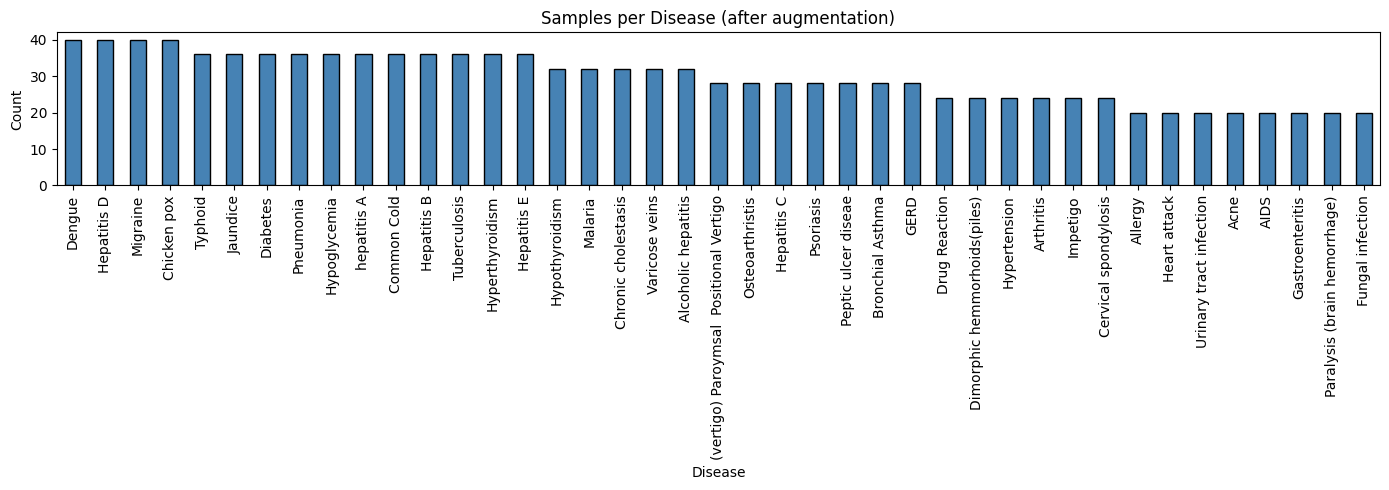

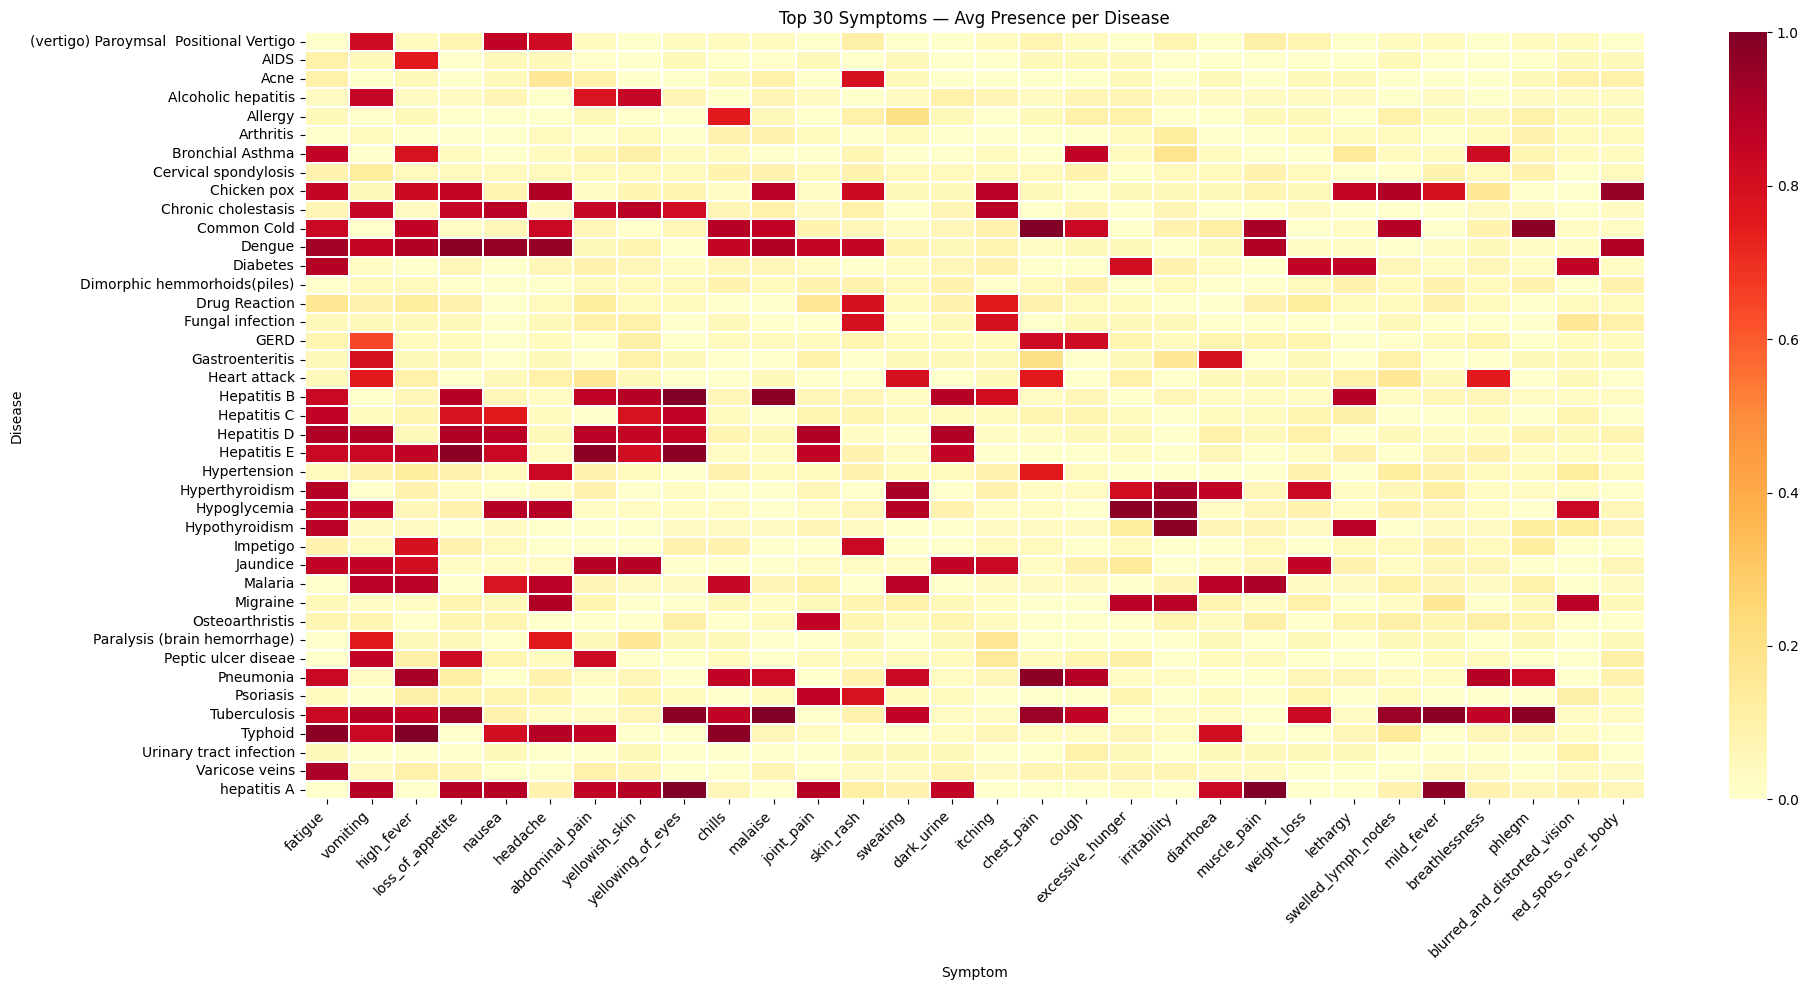

In [12]:
plt.figure(figsize=(14, 5))
augmented_df['Disease'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Samples per Disease (after augmentation)')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Symptom frequency heatmap (top 30 symptoms)
top_symptoms = augmented_df[all_symptoms].sum().sort_values(ascending=False).head(30).index.tolist()
disease_symptom_matrix = augmented_df.groupby('Disease')[top_symptoms].mean()

plt.figure(figsize=(20, 10))
sns.heatmap(disease_symptom_matrix, cmap='YlOrRd', linewidths=0.3)
plt.title('Top 30 Symptoms — Avg Presence per Disease')
plt.xlabel('Symptom')
plt.ylabel('Disease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.regularizers import l2
model = Sequential([
    Input(shape=(num_symptoms,)),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,145 (309.16 KB)

 Trainable params: 78,377 (306.16 KB)

 Non-trainable params: 768 (3.00 KB)

In [14]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# FIX 5: Reduce learning rate when val_loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.0528 - loss: 4.5412 - val_accuracy: 0.2103 - val_loss: 4.0406 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1557 - loss: 3.7754 - val_accuracy: 0.3128 - val_loss: 3.9192 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2754 - loss: 3.2072 - val_accuracy: 0.3897 - val_loss: 3.7612 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3990 - loss: 2.7974 - val_accuracy: 0.4000 - val_loss: 3.5757 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4723 - loss: 2.4798 - val_accuracy: 0.4769 - val_loss: 3.3487 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5470 - loss: 2.2249 - val_accuracy: 0.6205 - val_loss: 3.0811 - learning_rate: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5997 - loss: 2.0116 - val_accurac

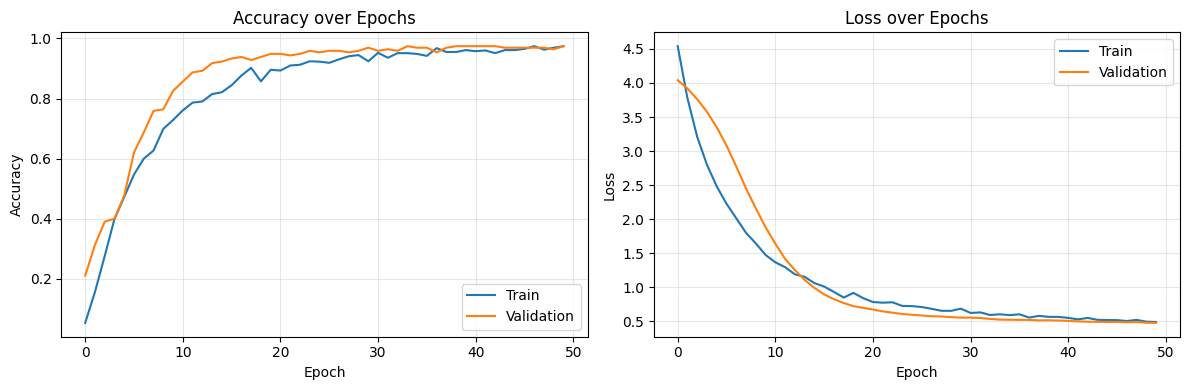

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
print(f"\nFinal Train Accuracy:      {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Gap (overfit indicator):   {abs(final_train_acc - final_val_acc)*100:.2f}%")
if abs(final_train_acc - final_val_acc) < 0.05:
    print("✅ Gap is small — model is generalizing well")
else:
    print("⚠️  Large gap — model may still be overfitting")


Final Train Accuracy:      97.43%
Final Validation Accuracy: 97.44%
Gap (overfit indicator):   0.01%
✅ Gap is small — model is generalizing well


In [17]:

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")


Test Accuracy: 96.31%
Test Loss:     0.4844


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step


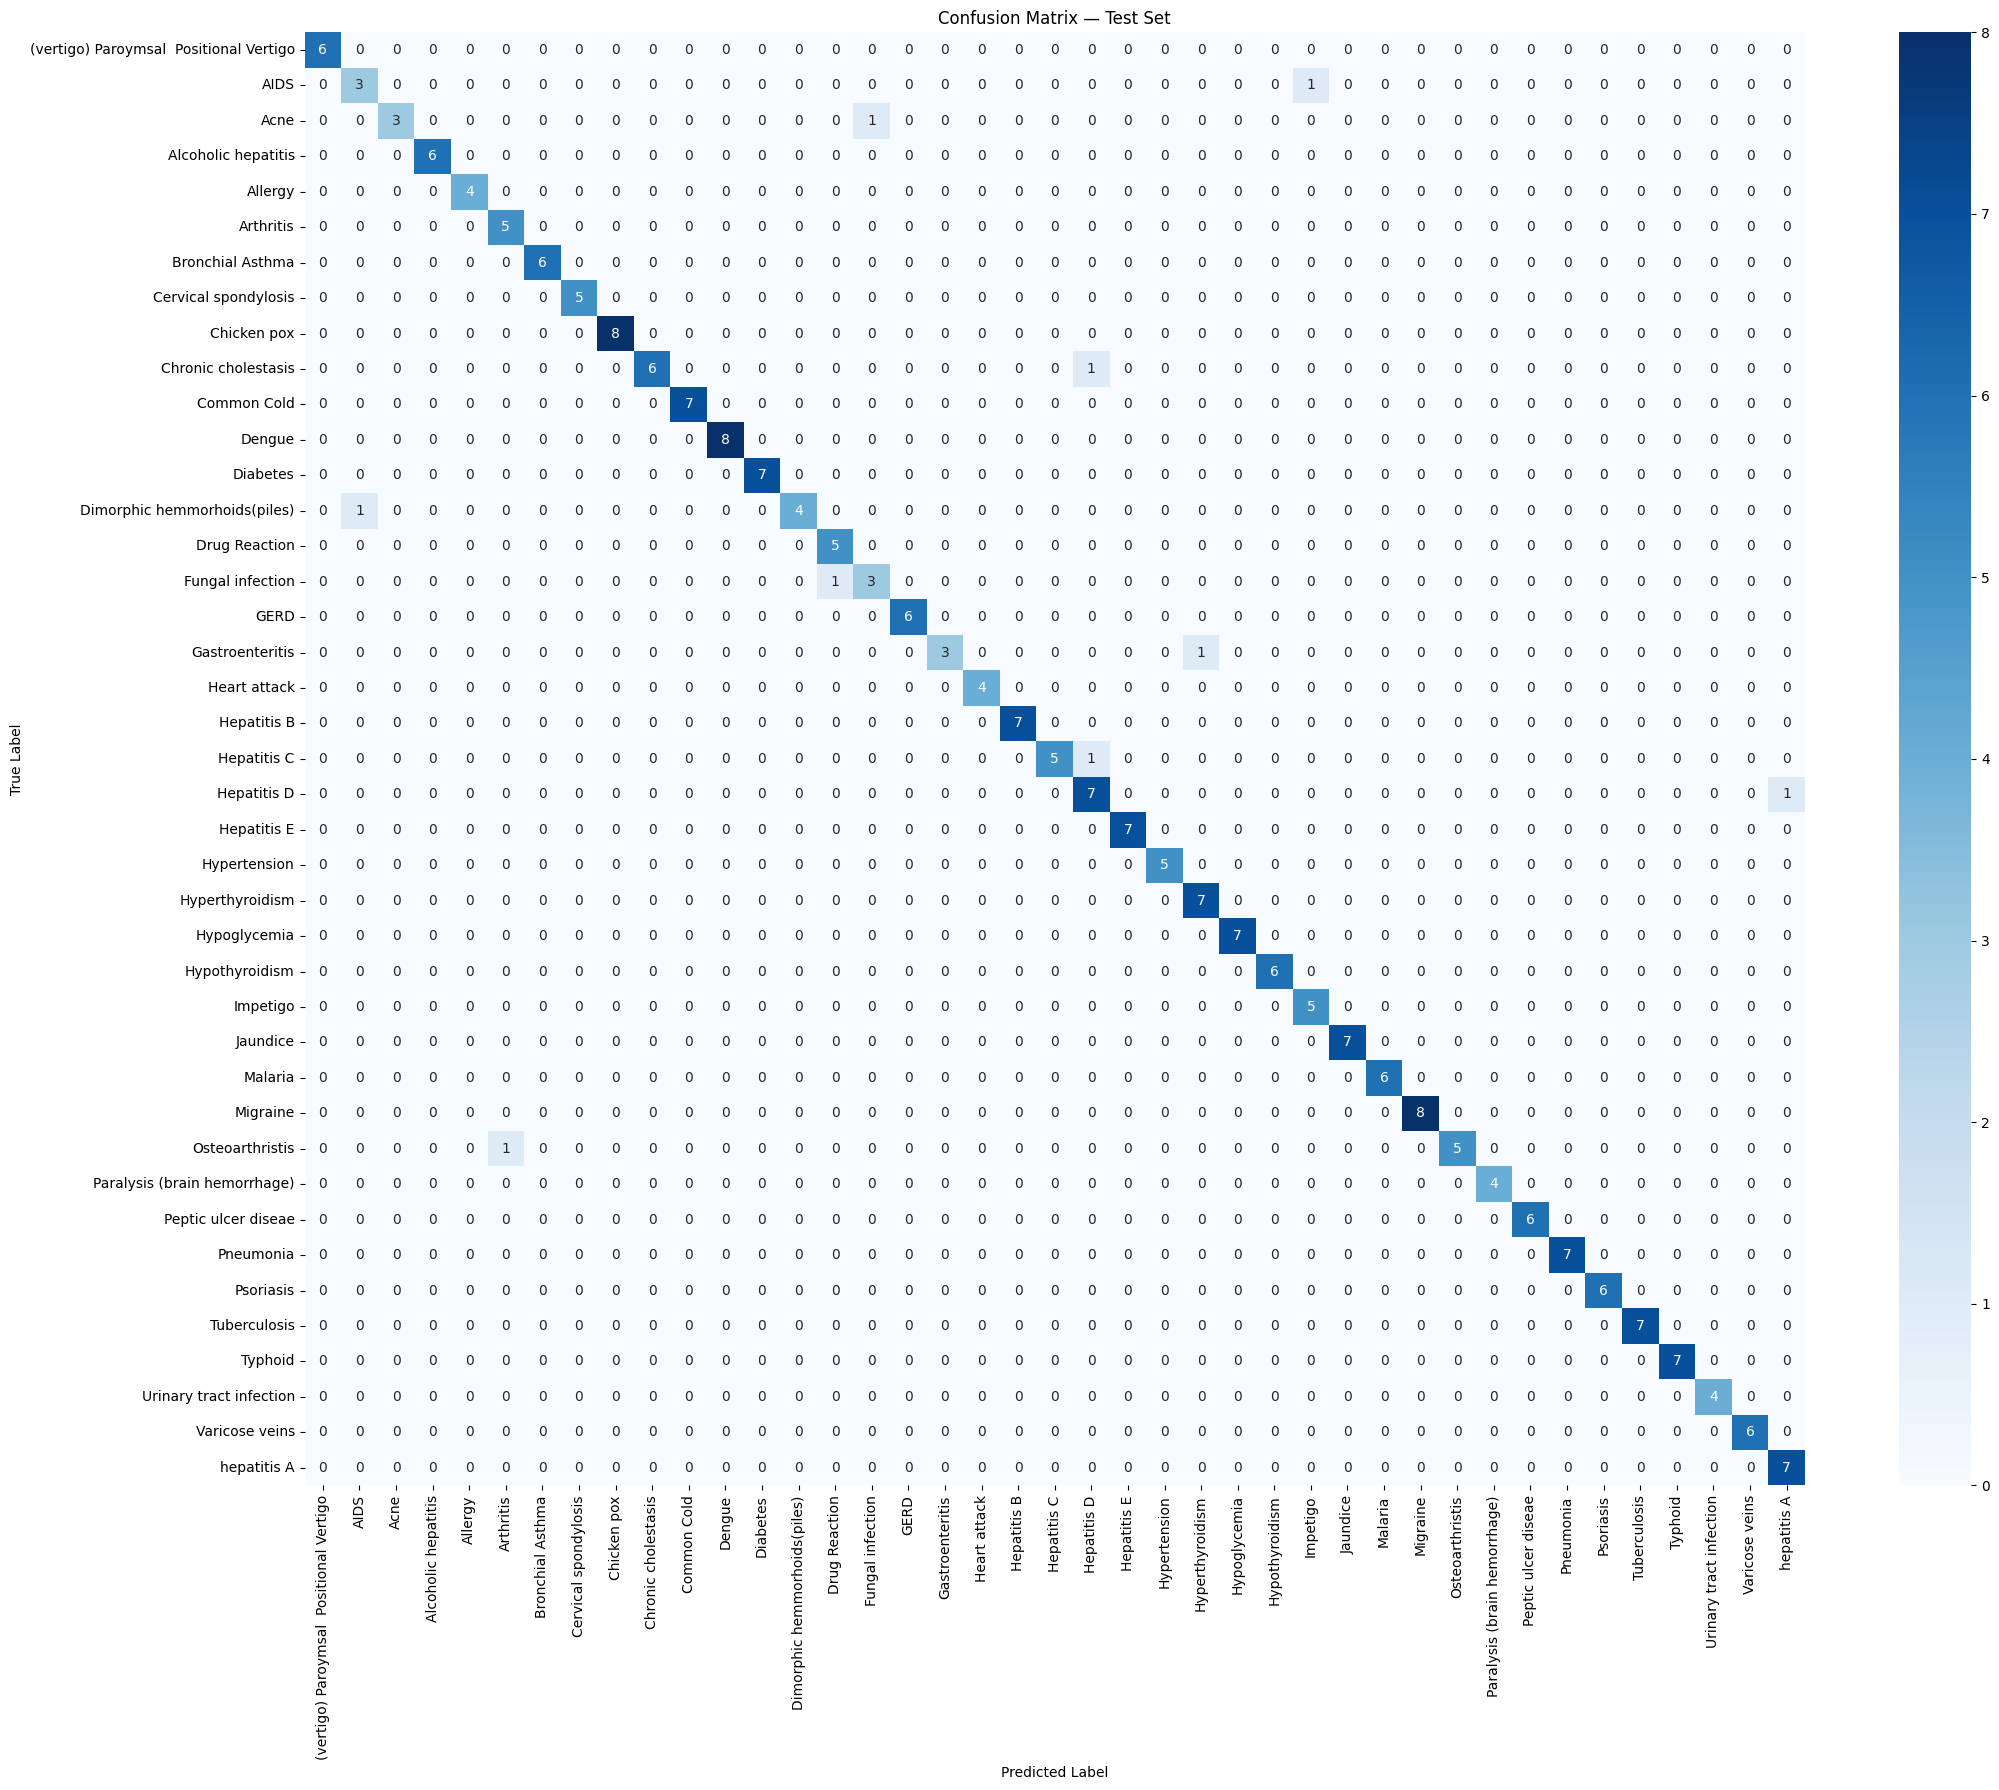


Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         6
                                   AIDS       0.75      0.75      0.75         4
                                   Acne       1.00      0.75      0.86         4
                    Alcoholic hepatitis       1.00      1.00      1.00         6
                                Allergy       1.00      1.00      1.00         4
                              Arthritis       0.83      1.00      0.91         5
                       Bronchial Asthma       1.00      1.00      1.00         6
                   Cervical spondylosis       1.00      1.00      1.00         5
                            Chicken pox       1.00      1.00      1.00         8
                    Chronic cholestasis       1.00      0.86      0.92         7
                            Common Cold       1.00      1.00      1.00         7
   

In [18]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(22, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_names,
            yticklabels=disease_names)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=disease_names))

In [ ]:
desc_df = pd.read_csv(DESCRIPTION_PATH)
desc_df['Disease'] = desc_df['Disease'].str.strip()
disease_descriptions = dict(zip(desc_df['Disease'], desc_df['Description']))

sev_df = pd.read_csv(SEVERITY_PATH)
sev_df['Symptom'] = sev_df['Symptom'].str.strip().str.lower().str.replace(' ', '_')
symptom_severity = dict(zip(sev_df['Symptom'], sev_df['weight'].astype(int)))

prec_df = pd.read_csv(PRECAUTION_PATH)
prec_df['Disease'] = prec_df['Disease'].str.strip()
disease_precautions = {}
for _, row in prec_df.iterrows():
    precs = [row[col] for col in prec_df.columns if col.startswith('Precaution_') and pd.notna(row[col])]
    disease_precautions[row['Disease']] = precs

In [ ]:
model_path = os.path.join(MODEL_DIR, "symptoms.keras")
model.save(model_path)
print(f"\n✅ Model saved → {model_path}")


✅ Model saved → /content/drive/MyDrive/MedicalAI/models/symptoms.keras


In [ ]:
metadata = {
    "symptoms": all_symptoms,
    "diseases": disease_names,
    "num_symptoms": num_symptoms,
    "num_classes": num_classes,
    "descriptions": disease_descriptions,
    "precautions": disease_precautions,
    "severity": symptom_severity
}

metadata_path = os.path.join(MODEL_DIR, "symptom_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Metadata saved → {metadata_path}")
print("\nAll done!")

✅ Metadata saved → /content/drive/MyDrive/MedicalAI/models/symptom_metadata.json

All done!
